# Notebook 07: Bootstrap Inference for Quantile Regression

**Series**: PanelBox Quantile Regression Tutorials  
**Level**: Intermediate-Advanced  
**Estimated Time**: 120 minutes  
**Prerequisites**: Notebooks 01 (Fundamentals), 02 (Multiple Quantiles), bootstrap basics

---

## Learning Objectives

By the end of this notebook you will be able to:

1. **Understand** why bootstrap is important for quantile regression inference
2. **Implement** cluster bootstrap for panel data
3. **Construct** robust confidence intervals (percentile, normal, BCa)
4. **Compare** bootstrap vs asymptotic standard errors
5. **Test** hypotheses using bootstrap
6. **Parallelize** bootstrap for computational efficiency

---

## Table of Contents

1. [Introduction & Motivation](#1)
2. [Theoretical Concepts](#2)
3. [Implementation](#3)
4. [Hypothesis Testing](#4)
5. [Computational Efficiency](#5)
6. [When to Use Bootstrap](#6)
7. [Exercises](#7)

## Setup

In [1]:
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

# PanelBox imports
import panelbox as pb
from panelbox.inference.quantile import QuantileBootstrap
from panelbox.models.quantile import PooledQuantile

# Suppress convergence warnings for pedagogy
warnings.filterwarnings("ignore", category=UserWarning)

# Reproducibility
np.random.seed(42)

# Plot style
plt.rcParams.update(
    {
        "figure.dpi": 120,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.3,
        "font.size": 11,
    }
)

# Define paths
BASE_DIR = Path("..")
DATA_DIR = BASE_DIR / "data"
OUTPUT_DIR = BASE_DIR / "outputs"
PLOTS_DIR = OUTPUT_DIR / "plots"
RESULTS_DIR = OUTPUT_DIR / "results"

# Create output directories
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"PanelBox version: {pb.__version__}")
print(f"NumPy version:    {np.__version__}")
print(f"Output dir:       {PLOTS_DIR}")

PanelBox version: 1.0.0
NumPy version:    2.3.5
Output dir:       ../outputs/plots


In [2]:
# --- Helper functions ---


def make_X(data, *cols):
    """Build design matrix with intercept."""
    arrays = [np.ones(len(data))] + [data[c].values.astype(float) for c in cols]
    return np.column_stack(arrays)


def make_fitted_model(model, result, tau_idx=0):
    """Add bootstrap-required attributes to a PooledQuantile model.

    The QuantileBootstrap class expects .X, .y, .entity_ids, .k_exog,
    .nobs, and .params on the model object. PooledQuantile stores these
    under .endog, .exog, .entity_id, so we create aliases.
    """
    model.X = model.exog
    model.y = model.endog
    model.entity_ids = model.entity_id
    model.k_exog = model.exog.shape[1]
    model.nobs = len(model.endog)
    model.params = result.params[:, tau_idx] if result.params.ndim == 2 else result.params
    return model


print("Helper functions defined.")

Helper functions defined.


---

## 1. Introduction & Motivation <a id="1"></a>

**Key Question**: *Can we trust the standard errors from quantile regression?*

Standard (asymptotic) inference in quantile regression requires estimating the **sparsity function** $s(\tau) = 1/f(Q_\tau)$, which involves kernel density estimation at the quantile of interest. This creates several problems:

| Challenge | Description |
|:---|:---|
| **Bandwidth selection** | Kernel density estimation requires a bandwidth — different choices yield different SEs |
| **Tail instability** | As $\tau \to 0$ or $\tau \to 1$, $f(Q_\tau) \to 0$ and sparsity explodes |
| **Panel dependence** | Within-entity correlation complicates the sandwich formula |
| **Finite-sample bias** | Asymptotic approximation may be poor for $n < 500$ |

**Bootstrap inference** avoids all of these issues:

```
BOOTSTRAP APPROACH:
1. Resample data B times
2. Re-estimate beta(tau) for each resample
3. Use empirical distribution of beta*(tau) for inference
4. No sparsity estimation needed!
```

---

## 2. Theoretical Concepts <a id="2"></a>

### 2.1 Why Bootstrap for Quantile Regression?

The asymptotic variance of the QR estimator is:

$$\text{Var}(\hat{\beta}(\tau)) \approx \tau(1-\tau) \cdot s(\tau)^2 \cdot (X'X)^{-1}$$

where $s(\tau) = 1/f(Q_\tau)$ is the **sparsity** (inverse of the density at the conditional quantile).

**Problems:**
1. Need to estimate $f(Q_\tau)$ — a bandwidth selection problem
2. $f(Q_\tau) \to 0$ at tails — unreliable SEs
3. Panel dependence complicates the formula

**Bootstrap solution:** Resample $B$ times, re-estimate, use the empirical distribution.

### 2.2 Bootstrap Methods for Panels

| Method | Resampling Unit | Panel-aware | Best for |
|:---|:---|:---:|:---|
| **Cluster** | Entire entities | Yes | Panel data (recommended) |
| **Pairs** | Individual $(y_i, x_i)$ pairs | No | Cross-section / i.i.d. |
| **Wild** | Residuals with random signs | No | Heteroskedasticity |
| **Subsampling** | Subset without replacement | Optional | Weak assumptions |

**Cluster Bootstrap Algorithm:**
```
For b = 1 to B:
  1. Draw N entities with replacement from {1, ..., N}
  2. Include ALL T observations for each drawn entity
  3. Estimate beta(tau) on bootstrap sample
  4. Store beta*(b)

SE_boot  = std({beta*(b)})
CI_perc  = [q_{alpha/2}, q_{1-alpha/2}] of bootstrap distribution
```

**Critical**: Resample at the **entity** level, not observation level, to preserve within-entity correlation.

### 2.3 Confidence Interval Methods

**1. Percentile CI** (recommended):
$$\text{CI} = [q_{\alpha/2},\; q_{1-\alpha/2}]$$
Uses empirical quantiles of the bootstrap distribution. Handles asymmetry.

**2. Normal CI:**
$$\text{CI} = \hat{\beta} \pm z_{\alpha/2} \cdot \text{SE}_{\text{boot}}$$
Assumes the bootstrap distribution is approximately normal.

**3. BCa (Bias-Corrected Accelerated):**
Adjusts percentile cutoffs for both bias and skewness. Most accurate in small samples but computationally intensive.

---

## 3. Implementation <a id="3"></a>

### 3.1 Load Data

In [3]:
# Load wage panel data
data = pd.read_csv(DATA_DIR / "card_education.csv")

print(f"Dataset shape: {data.shape}")
print(f"Variables: {data.columns.tolist()}")
print(f"N observations: {len(data)}")
print(f"N individuals: {data['id'].nunique()}")
print(f"N periods: {data['year'].nunique()}")
print()
display(data.head(10))

# Check for missing values
missing = data.isnull().sum()
if missing.any():
    print("\nMissing values:")
    print(missing[missing > 0])
else:
    print("\nNo missing values.")

Dataset shape: (3000, 12)
Variables: ['id', 'year', 'lwage', 'educ', 'exper', 'black', 'south', 'married', 'female', 'union', 'hours', 'age']
N observations: 3000
N individuals: 500
N periods: 6



,id,year,lwage,educ,exper,black,south,married,female,union,hours,age
0,1,1,4.2353,13.2,19.6,1,0,0,1,0,38.5,39.7
1,1,2,2.5440,13.2,23.5,1,0,0,1,1,40.8,40.7
2,1,3,4.2175,13.2,20.8,1,0,1,1,0,31.8,41.7
3,1,4,3.0313,13.2,23.6,1,0,1,1,1,41.8,42.7
4,1,5,2.0460,13.2,26.5,1,0,0,1,0,26.2,43.7
5,1,6,-0.1506,13.2,25.5,1,0,1,1,0,48.4,44.7
6,2,1,0.8219,11.7,10.2,0,0,1,1,0,40.4,28.1
7,2,2,4.7381,11.7,11.1,0,0,0,1,0,35.8,29.1
8,2,3,0.9750,11.7,12.2,0,0,1,1,0,33.3,30.1
9,2,4,-0.5171,11.7,14.8,0,0,0,1,0,38.1,31.1



No missing values.


### 3.2 Asymptotic Inference (Baseline)

First, we estimate the model with cluster-robust asymptotic standard errors as the baseline.

In [4]:
# Prepare data arrays
y = data["lwage"].values
X = make_X(data, "educ", "exper")
entity_id = data["id"].values
var_names = ["const", "educ", "exper"]

# Fit median quantile regression with cluster-robust SEs
model = PooledQuantile(y, X, entity_id=entity_id, quantiles=0.5)
result = model.fit(se_type="cluster")

# Extract coefficients and standard errors
params_arr = result.params.ravel()
se_asymptotic = result.std_errors.ravel()

print("ASYMPTOTIC INFERENCE (Cluster-Robust SEs)")
print("=" * 60)
print(f"{'Variable':<15} {'Coef':>10} {'Std.Err':>10} {'t-stat':>10} {'p-value':>10}")
print("-" * 60)
for name, coef, se in zip(var_names, params_arr, se_asymptotic):
    t_stat = coef / se
    p_val = 2 * (1 - stats.norm.cdf(abs(t_stat)))
    print(f"{name:<15} {coef:10.4f} {se:10.4f} {t_stat:10.3f} {p_val:10.4f}")
print("=" * 60)

ASYMPTOTIC INFERENCE (Cluster-Robust SEs)
Variable              Coef    Std.Err     t-stat    p-value
------------------------------------------------------------
const               0.6248     0.0145     43.204     0.0000
educ                0.0840     0.0009     90.428     0.0000
exper               0.0197     0.0004     52.977     0.0000


### 3.3 Bootstrap Inference

Now we use the `QuantileBootstrap` class to compute bootstrap standard errors and confidence intervals using the cluster bootstrap method.

In [5]:
# Prepare the model for bootstrap
# QuantileBootstrap expects .X, .y, .entity_ids attributes on the model
make_fitted_model(model, result)

# Initialize bootstrap
bs = QuantileBootstrap(
    model=model,
    tau=0.5,
    n_boot=999,  # Number of bootstrap replications
    method="cluster",  # Cluster bootstrap for panels
    ci_method="percentile",  # CI construction method
    random_state=42,
)

# Run bootstrap (parallelized)
print("Running cluster bootstrap (B=999, parallel)...")
t0 = time.time()
bs_result = bs.bootstrap(n_jobs=-1, verbose=True)
elapsed = time.time() - t0

# Check convergence
valid_mask = ~np.any(np.isnan(bs_result.boot_params), axis=1)
print(f"\nTime elapsed: {elapsed:.1f}s")
print(f"Valid replications: {valid_mask.sum()} / {bs_result.n_boot}")

# Display results
print("\nBOOTSTRAP INFERENCE (Cluster Bootstrap, Percentile CI)")
bs_result.summary(var_names=var_names)

Running cluster bootstrap (B=999, parallel)...


Bootstrap:   0%|          | 0/999 [00:00<?, ?it/s]

Bootstrap:   4%|▍         | 44/999 [00:02<00:50, 18.89it/s]

Bootstrap:   7%|▋         | 66/999 [00:02<00:32, 28.74it/s]

Bootstrap:  13%|█▎        | 132/999 [00:02<00:12, 71.82it/s]

...

Bootstrap:  53%|█████▎    | 528/999 [00:03<00:01, 414.73it/s]

Bootstrap:  70%|███████   | 704/999 [00:03<00:00, 512.49it/s]

Bootstrap:  88%|████████▊ | 880/999 [00:03<00:00, 537.13it/s]

Bootstrap: 100%|██████████| 999/999 [00:03<00:00, 271.46it/s]


Time elapsed: 4.4s
Valid replications: 998 / 999

BOOTSTRAP INFERENCE (Cluster Bootstrap, Percentile CI)

Bootstrap Results (cluster, B=999)
Variable                SE   CI Lower   CI Upper
----------------------------------------------------------------------
const               0.1802     0.3044     0.9743
educ                0.0125     0.0600     0.1084
exper               0.0047     0.0099     0.0280


### 3.4 Compare Asymptotic vs Bootstrap Standard Errors

In [6]:
# Comparison table
se_bootstrap = bs_result.se

comparison = pd.DataFrame(
    {
        "Variable": var_names,
        "SE_Asymptotic": se_asymptotic,
        "SE_Bootstrap": se_bootstrap,
    }
)
comparison["Ratio"] = comparison["SE_Bootstrap"] / comparison["SE_Asymptotic"]
comparison["Difference"] = comparison["SE_Bootstrap"] - comparison["SE_Asymptotic"]

print("STANDARD ERROR COMPARISON")
print("=" * 65)
display(comparison)
print()
print("Interpretation:")
print("  Ratio > 1: Bootstrap SE is larger (asymptotic may be overconfident)")
print("  Ratio < 1: Bootstrap SE is smaller (asymptotic may be conservative)")
print("  Ratio ~ 1: Both methods agree")

STANDARD ERROR COMPARISON


,Variable,SE_Asymptotic,SE_Bootstrap,Ratio,Difference
0,const,0.014462,0.180208,12.460980,0.165746
1,educ,0.000929,0.012473,13.433007,0.011545
2,exper,0.000372,0.004705,12.646971,0.004333



Interpretation:
  Ratio > 1: Bootstrap SE is larger (asymptotic may be overconfident)
  Ratio < 1: Bootstrap SE is smaller (asymptotic may be conservative)
  Ratio ~ 1: Both methods agree


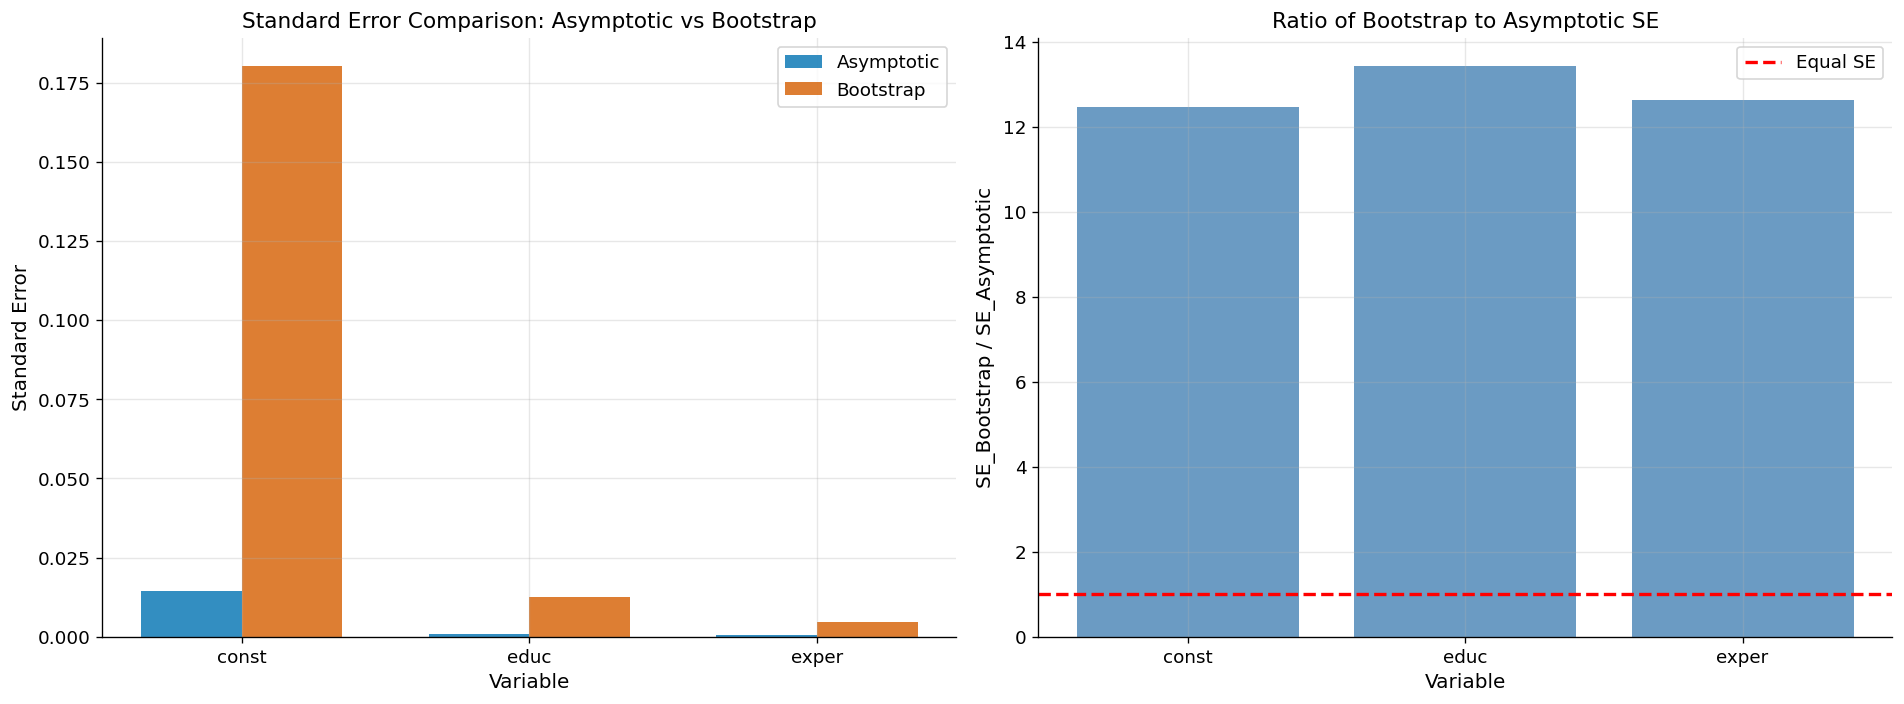

Plot saved to ../outputs/plots/07_se_comparison.png


In [7]:
# Visualize the comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Side-by-side bar chart
x = np.arange(len(comparison))
width = 0.35

ax1.bar(
    x - width / 2,
    comparison["SE_Asymptotic"],
    width,
    label="Asymptotic",
    alpha=0.8,
    color="#0072B2",
)
ax1.bar(
    x + width / 2, comparison["SE_Bootstrap"], width, label="Bootstrap", alpha=0.8, color="#D55E00"
)

ax1.set_xlabel("Variable", fontsize=12)
ax1.set_ylabel("Standard Error", fontsize=12)
ax1.set_title("Standard Error Comparison: Asymptotic vs Bootstrap", fontsize=13)
ax1.set_xticks(x)
ax1.set_xticklabels(comparison["Variable"])
ax1.legend(fontsize=11)

# Plot 2: Ratio
colors = ["steelblue" if r >= 1 else "#E69F00" for r in comparison["Ratio"]]
ax2.bar(comparison["Variable"], comparison["Ratio"], alpha=0.8, color=colors)
ax2.axhline(1, color="red", linestyle="--", linewidth=2, label="Equal SE")
ax2.set_xlabel("Variable", fontsize=12)
ax2.set_ylabel("SE_Bootstrap / SE_Asymptotic", fontsize=12)
ax2.set_title("Ratio of Bootstrap to Asymptotic SE", fontsize=13)
ax2.legend(fontsize=11)

plt.tight_layout()
plt.savefig(PLOTS_DIR / "07_se_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"Plot saved to {PLOTS_DIR / '07_se_comparison.png'}")

### 3.5 Bootstrap Distribution Visualization

Visualizing the bootstrap distribution gives insight into the shape of the sampling distribution for each coefficient.

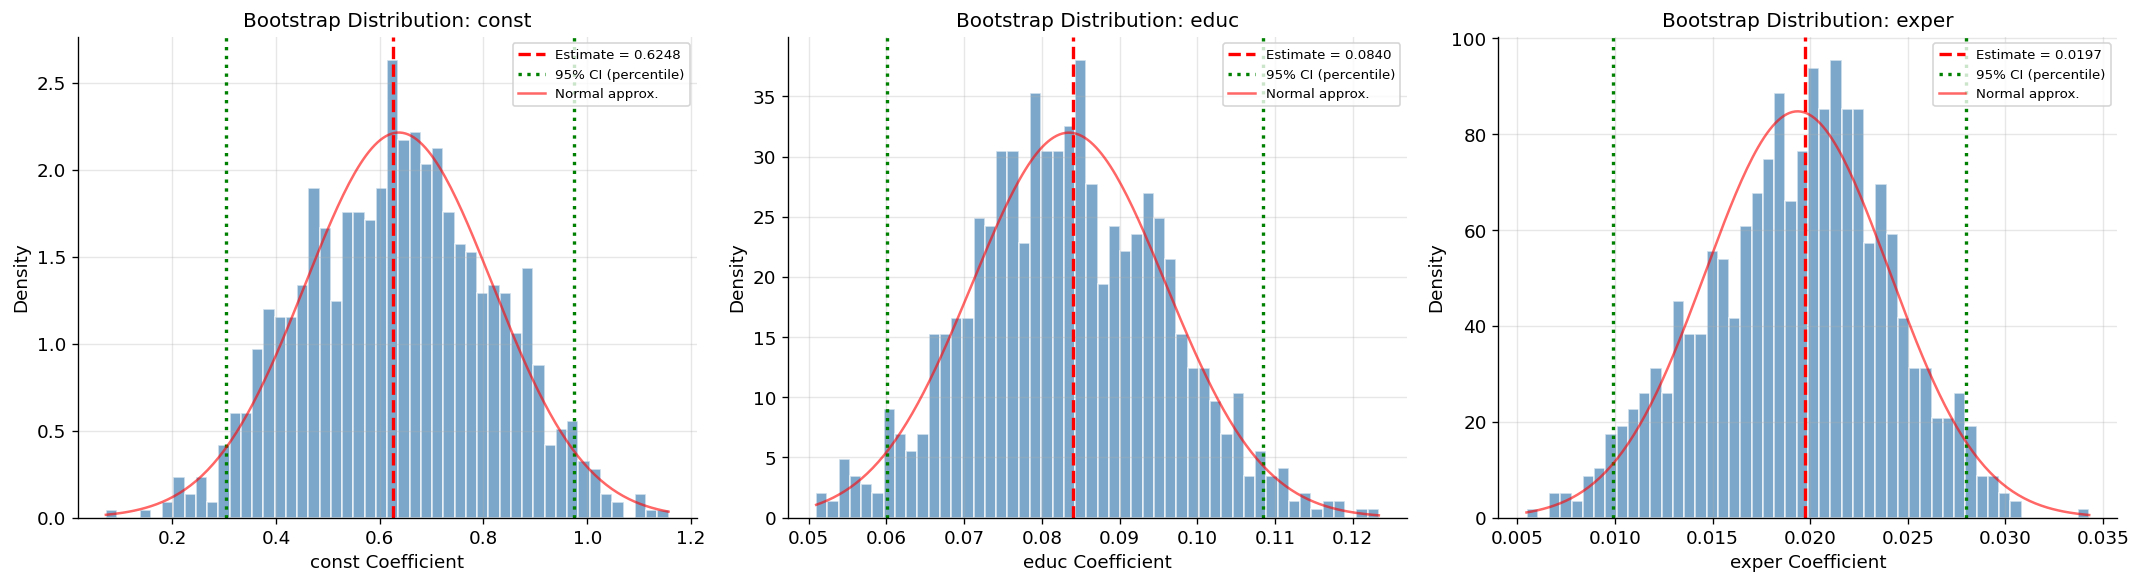

Plot saved to ../outputs/plots/07_bootstrap_distributions.png

Bootstrap Distribution Diagnostics:
Variable         Mean        Std   Skewness   Kurtosis
-------------------------------------------------------
const          0.6368     0.1802    -0.0019    -0.3867
educ           0.0835     0.0125     0.1005    -0.1655
exper          0.0194     0.0047    -0.2008    -0.2823


In [8]:
# Remove NaN rows for clean visualization
boot_valid = bs_result.boot_params[valid_mask]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (var, ax) in enumerate(zip(var_names, axes)):
    # Get bootstrap samples for this variable
    boot_samples = boot_valid[:, idx]

    # Histogram
    ax.hist(boot_samples, bins=50, alpha=0.7, edgecolor="white", density=True, color="steelblue")

    # Original estimate
    original = params_arr[idx]
    ax.axvline(
        original, color="red", linestyle="--", linewidth=2, label=f"Estimate = {original:.4f}"
    )

    # Bootstrap CI
    ci_lower = bs_result.ci_lower[idx]
    ci_upper = bs_result.ci_upper[idx]
    ax.axvline(ci_lower, color="green", linestyle=":", linewidth=2, label="95% CI (percentile)")
    ax.axvline(ci_upper, color="green", linestyle=":", linewidth=2)

    # Normal approximation overlay
    mu, sigma = boot_samples.mean(), boot_samples.std()
    x_norm = np.linspace(boot_samples.min(), boot_samples.max(), 200)
    ax.plot(
        x_norm,
        stats.norm.pdf(x_norm, mu, sigma),
        "r-",
        linewidth=1.5,
        alpha=0.6,
        label="Normal approx.",
    )

    ax.set_xlabel(f"{var} Coefficient", fontsize=11)
    ax.set_ylabel("Density", fontsize=11)
    ax.set_title(f"Bootstrap Distribution: {var}", fontsize=12)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(PLOTS_DIR / "07_bootstrap_distributions.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"Plot saved to {PLOTS_DIR / '07_bootstrap_distributions.png'}")

# Normality diagnostics
print("\nBootstrap Distribution Diagnostics:")
print(f"{'Variable':<10} {'Mean':>10} {'Std':>10} {'Skewness':>10} {'Kurtosis':>10}")
print("-" * 55)
for idx, var in enumerate(var_names):
    samples = boot_valid[:, idx]
    print(
        f"{var:<10} {samples.mean():10.4f} {samples.std():10.4f} "
        f"{stats.skew(samples):10.4f} {stats.kurtosis(samples):10.4f}"
    )

---

## 4. Hypothesis Testing <a id="4"></a>

### 4.1 Bootstrap t-test

We test $H_0: \beta_{\text{educ}} = 0$ using bootstrap inference.

In [9]:
# Test H0: beta_educ = 0 using bootstrap
educ_idx = 1  # index of 'educ' in var_names

# Method 1: Check if 0 is in bootstrap CI
ci_lower_educ = bs_result.ci_lower[educ_idx]
ci_upper_educ = bs_result.ci_upper[educ_idx]
contains_zero = ci_lower_educ <= 0 <= ci_upper_educ

print("=== Bootstrap Test: H0: beta_educ = 0 ===")
print("\nMethod 1: CI Inversion")
print(f"  Bootstrap CI for educ: [{ci_lower_educ:.4f}, {ci_upper_educ:.4f}]")
print(f"  Contains zero: {contains_zero}")
print(f"  Result: {'FAIL TO REJECT H0' if contains_zero else 'REJECT H0 at 5%'}")

# Method 2: Bootstrap p-value
# Two-sided p-value: proportion of bootstrap estimates with |beta*| >= |beta_hat|
beta_educ_boot = boot_valid[:, educ_idx]
beta_educ_hat = params_arr[educ_idx]

# Center bootstrap distribution under H0
beta_centered = beta_educ_boot - beta_educ_hat  # center at zero
p_value_boot = np.mean(np.abs(beta_centered) >= np.abs(beta_educ_hat))

print("\nMethod 2: Bootstrap p-value")
print(f"  Original estimate: {beta_educ_hat:.4f}")
print(f"  Bootstrap p-value: {p_value_boot:.4f}")
print(f"  Result: {'REJECT H0 at 5%' if p_value_boot < 0.05 else 'FAIL TO REJECT H0'}")

=== Bootstrap Test: H0: beta_educ = 0 ===

Method 1: CI Inversion
  Bootstrap CI for educ: [0.0600, 0.1084]
  Contains zero: False
  Result: REJECT H0 at 5%

Method 2: Bootstrap p-value
  Original estimate: 0.0840
  Bootstrap p-value: 0.0000
  Result: REJECT H0 at 5%


### 4.2 Inter-Quantile Test (Bootstrap)

Test whether the education effect differs between the 25th and 75th percentiles:

$$H_0: \beta_{\text{educ}}(0.25) = \beta_{\text{educ}}(0.75)$$

In [10]:
# Estimate at tau=0.25 and tau=0.75 with bootstrap
print("Estimating quantile models at tau=0.25 and tau=0.75 with bootstrap...")

# tau = 0.25
model_25 = PooledQuantile(y, X, entity_id=entity_id, quantiles=0.25)
result_25 = model_25.fit(se_type="cluster")
make_fitted_model(model_25, result_25)

bs_25 = QuantileBootstrap(
    model_25, tau=0.25, n_boot=999, method="cluster", ci_method="percentile", random_state=42
)
boot_25 = bs_25.bootstrap(n_jobs=-1, verbose=False)

# tau = 0.75
model_75 = PooledQuantile(y, X, entity_id=entity_id, quantiles=0.75)
result_75 = model_75.fit(se_type="cluster")
make_fitted_model(model_75, result_75)

bs_75 = QuantileBootstrap(
    model_75, tau=0.75, n_boot=999, method="cluster", ci_method="percentile", random_state=42
)
boot_75 = bs_75.bootstrap(n_jobs=-1, verbose=False)

# Valid replications in both
valid_25 = ~np.any(np.isnan(boot_25.boot_params), axis=1)
valid_75 = ~np.any(np.isnan(boot_75.boot_params), axis=1)
valid_both = valid_25 & valid_75

print(f"Valid replications at tau=0.25: {valid_25.sum()}")
print(f"Valid replications at tau=0.75: {valid_75.sum()}")
print(f"Valid in both: {valid_both.sum()}")

# Compute difference in education coefficient
beta_25 = boot_25.boot_params[valid_both, educ_idx]
beta_75 = boot_75.boot_params[valid_both, educ_idx]
diff_boot = beta_75 - beta_25

# Observed difference
obs_diff = result_75.params.ravel()[educ_idx] - result_25.params.ravel()[educ_idx]

# Bootstrap CI for difference
ci_diff_lower = np.percentile(diff_boot, 2.5)
ci_diff_upper = np.percentile(diff_boot, 97.5)

# Bootstrap p-value
p_value_diff = 2 * min(np.mean(diff_boot >= obs_diff), np.mean(diff_boot <= obs_diff))

print("\n=== Inter-Quantile Test: H0: beta_educ(0.25) = beta_educ(0.75) ===")
print(f"beta_educ(0.25) = {result_25.params.ravel()[educ_idx]:.4f}")
print(f"beta_educ(0.75) = {result_75.params.ravel()[educ_idx]:.4f}")
print(f"Observed difference: {obs_diff:.4f}")
print(f"Bootstrap SE of difference: {np.std(diff_boot):.4f}")
print(f"Bootstrap CI: [{ci_diff_lower:.4f}, {ci_diff_upper:.4f}]")
print(f"Bootstrap p-value: {p_value_diff:.4f}")
print()
if ci_diff_lower > 0 or ci_diff_upper < 0:
    print("-> REJECT H0: Significant heterogeneity across quantiles")
else:
    print("-> FAIL TO REJECT H0: No significant difference detected")

Estimating quantile models at tau=0.25 and tau=0.75 with bootstrap...


Valid replications at tau=0.25: 174
Valid replications at tau=0.75: 265
Valid in both: 46

=== Inter-Quantile Test: H0: beta_educ(0.25) = beta_educ(0.75) ===
beta_educ(0.25) = 0.0368
beta_educ(0.75) = 0.1414
Observed difference: 0.1046
Bootstrap SE of difference: 0.0201
Bootstrap CI: [0.0737, 0.1467]
Bootstrap p-value: 0.8261

-> REJECT H0: Significant heterogeneity across quantiles


---

## 5. Computational Efficiency <a id="5"></a>

Bootstrap is computationally intensive. We benchmark different values of $B$ and demonstrate the importance of parallelization.

In [11]:
import multiprocessing

n_cores = multiprocessing.cpu_count()
print(f"Available CPU cores: {n_cores}")
print()

# Compare different B values
B_values = [99, 199, 499, 999]
timing_results = []
se_stability = []

for B in B_values:
    bs_temp = QuantileBootstrap(model, tau=0.5, n_boot=B, method="cluster", random_state=42)

    start = time.time()
    boot_temp = bs_temp.bootstrap(n_jobs=-1, verbose=False)
    elapsed = time.time() - start

    timing_results.append({"B": B, "Time": elapsed})
    se_stability.append(
        {
            "B": B,
            "SE_educ": np.nanstd(boot_temp.boot_params[:, educ_idx]),
            "CI_width_educ": boot_temp.ci_upper[educ_idx] - boot_temp.ci_lower[educ_idx],
        }
    )
    valid = (~np.any(np.isnan(boot_temp.boot_params), axis=1)).sum()
    print(
        f"B={B:4d}: {elapsed:.2f}s  |  SE(educ)={se_stability[-1]['SE_educ']:.4f}  "
        f"|  CI width={se_stability[-1]['CI_width_educ']:.4f}  |  valid={valid}/{B}"
    )

Available CPU cores: 22



B=  99: 0.19s  |  SE(educ)=0.0121  |  CI width=0.0472  |  valid=99/99


B= 199: 0.31s  |  SE(educ)=0.0119  |  CI width=0.0443  |  valid=199/199


B= 499: 0.71s  |  SE(educ)=0.0121  |  CI width=0.0473  |  valid=498/499


B= 999: 1.28s  |  SE(educ)=0.0125  |  CI width=0.0484  |  valid=998/999


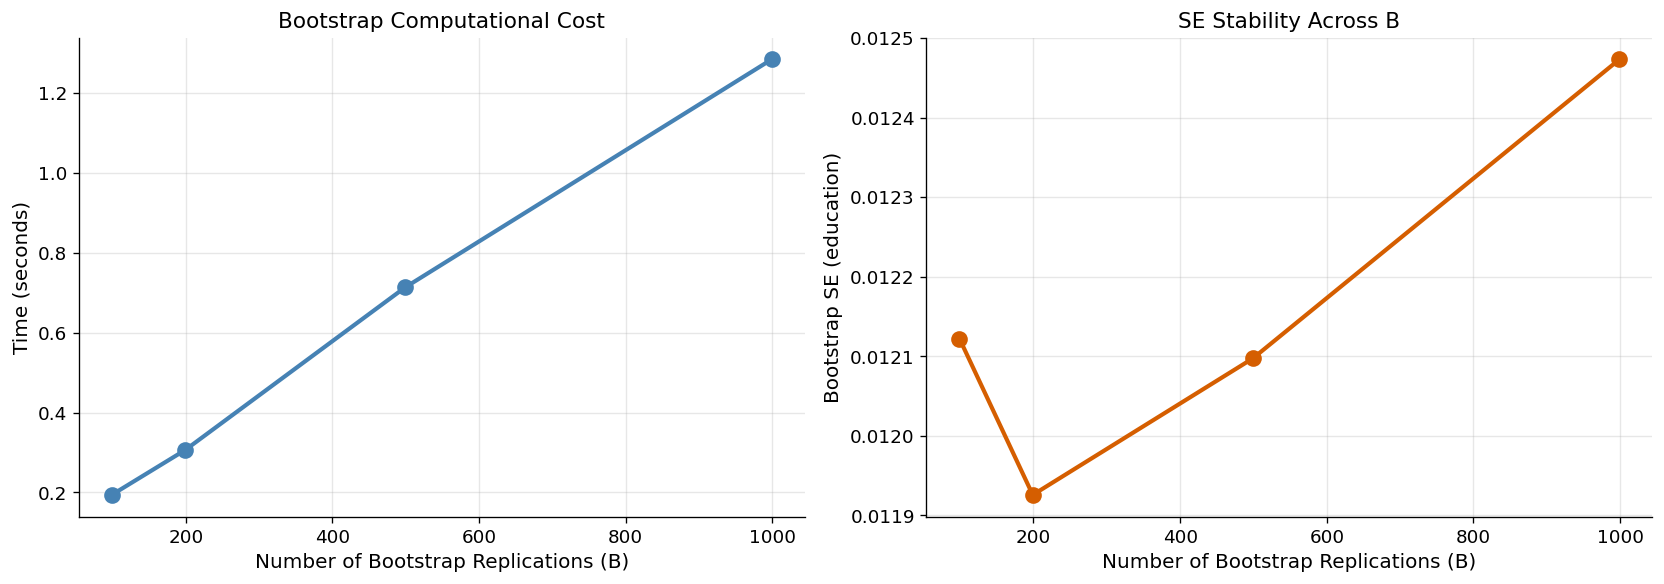

Plot saved to ../outputs/plots/07_bootstrap_timing.png

RECOMMENDATION:
  - Exploratory: B=199
  - Standard: B=999
  - Publication: B=1999 or more


In [12]:
# Plot timing results
timing_df = pd.DataFrame(timing_results)
se_df = pd.DataFrame(se_stability)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: Computational cost
ax1.plot(timing_df["B"], timing_df["Time"], "o-", linewidth=2.5, markersize=9, color="steelblue")
ax1.set_xlabel("Number of Bootstrap Replications (B)", fontsize=12)
ax1.set_ylabel("Time (seconds)", fontsize=12)
ax1.set_title("Bootstrap Computational Cost", fontsize=13)

# Right: SE stability
ax2.plot(se_df["B"], se_df["SE_educ"], "o-", linewidth=2.5, markersize=9, color="#D55E00")
ax2.set_xlabel("Number of Bootstrap Replications (B)", fontsize=12)
ax2.set_ylabel("Bootstrap SE (education)", fontsize=12)
ax2.set_title("SE Stability Across B", fontsize=13)

plt.tight_layout()
plt.savefig(PLOTS_DIR / "07_bootstrap_timing.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"Plot saved to {PLOTS_DIR / '07_bootstrap_timing.png'}")
print()
print("RECOMMENDATION:")
print("  - Exploratory: B=199")
print("  - Standard: B=999")
print("  - Publication: B=1999 or more")

---

## 6. When to Use Bootstrap <a id="6"></a>

In [13]:
print("=== Decision Guide: Bootstrap vs Asymptotic ===")
print()
print("USE BOOTSTRAP when:")
print("  + Panels (always use cluster bootstrap)")
print("  + Small samples (n < 500)")
print("  + Tails (tau < 0.1 or tau > 0.9)")
print("  + Complex models (FE, IV, etc.)")
print("  + Hypothesis testing (inter-quantile tests)")
print("  + Publication / high-stakes inference")
print()
print("USE ASYMPTOTIC when:")
print("  + Very large samples (n > 10,000) and computational constraints")
print("  + Interior quantiles (0.2 < tau < 0.8)")
print("  + Exploratory analysis (quick results)")
print()
print("ALWAYS COMPARE BOTH when possible.")
print()
print("PRACTICAL TIPS:")
print("  1. Prototype with B=99-199, finalize with B=999+")
print("  2. Always use n_jobs=-1 for parallelization")
print("  3. Check convergence: valid_mask = ~np.any(np.isnan(boot.boot_params), axis=1)")
print("  4. If >5% NaN: increase max_iter or check data quality")
print("  5. Use percentile CIs — robust to skewness")

=== Decision Guide: Bootstrap vs Asymptotic ===

USE BOOTSTRAP when:
  + Panels (always use cluster bootstrap)
  + Small samples (n < 500)
  + Tails (tau < 0.1 or tau > 0.9)
  + Complex models (FE, IV, etc.)
  + Hypothesis testing (inter-quantile tests)
  + Publication / high-stakes inference

USE ASYMPTOTIC when:
  + Very large samples (n > 10,000) and computational constraints
  + Interior quantiles (0.2 < tau < 0.8)
  + Exploratory analysis (quick results)

ALWAYS COMPARE BOTH when possible.

PRACTICAL TIPS:
  1. Prototype with B=99-199, finalize with B=999+
  2. Always use n_jobs=-1 for parallelization
  3. Check convergence: valid_mask = ~np.any(np.isnan(boot.boot_params), axis=1)
  4. If >5% NaN: increase max_iter or check data quality
  5. Use percentile CIs — robust to skewness


---

## 7. Exercises <a id="7"></a>

### Exercise 1: Naive vs Cluster Bootstrap (Easy)

**Objective**: Compare the naive (pairs) bootstrap, which ignores panel structure, with the cluster bootstrap.

**Tasks**:
1. Run `QuantileBootstrap` with `method='pairs'` (B=499)
2. Run `QuantileBootstrap` with `method='cluster'` (B=499)
3. Compare standard errors for each variable
4. Explain why they differ

In [14]:
# Exercise 1: YOUR CODE HERE

# Hint: Use the same model object (already prepared with make_fitted_model)
# bs_pairs = QuantileBootstrap(model, tau=0.5, n_boot=499, method='pairs', ...)
# bs_cluster = QuantileBootstrap(model, tau=0.5, n_boot=499, method='cluster', ...)



### Exercise 2: CI Stability Across B (Easy)

**Objective**: Investigate how stable confidence intervals are as B increases.

**Tasks**:
1. Run bootstrap with B = 99, 199, 499, 999, 1999
2. Record the 95% CI for the education coefficient at each B
3. Plot CI bounds vs B
4. At what B do CIs stabilize?

In [15]:
# Exercise 2: YOUR CODE HERE

# B_list = [99, 199, 499, 999, 1999]
# ci_lower_list = []
# ci_upper_list = []
# for B in B_list:
#     ...



### Exercise 3: Compare CI Methods (Medium)

**Objective**: Compare three confidence interval methods: percentile, normal, and BCa.

**Tasks**:
1. Run bootstrap with B=999 and `ci_method='percentile'`
2. Run bootstrap with B=999 and `ci_method='normal'`
3. Run bootstrap with B=999 and `ci_method='bca'`
4. Create a comparison table showing CI bounds for each variable under each method
5. Which method gives the widest CIs? Which the narrowest?

In [16]:
# Exercise 3: YOUR CODE HERE

# ci_methods = ['percentile', 'normal', 'bca']
# results_ci = {}
# for method in ci_methods:
#     bs_temp = QuantileBootstrap(model, tau=0.5, n_boot=999,
#                                 method='cluster', ci_method=method, random_state=42)
#     ...



### Exercise 4: Multi-Quantile Bootstrap Process (Medium)

**Objective**: Run bootstrap inference at multiple quantiles and test if the coefficient path is significantly non-flat.

**Tasks**:
1. Estimate QR at tau = {0.1, 0.25, 0.5, 0.75, 0.9} with cluster bootstrap (B=499)
2. Plot the education coefficient path with bootstrap confidence bands
3. Test whether the coefficient differs significantly between tau=0.1 and tau=0.9
4. Is the coefficient path significantly non-flat?

In [17]:
# Exercise 4: YOUR CODE HERE

# taus = [0.1, 0.25, 0.5, 0.75, 0.9]
# coefs_educ = []
# ci_lo_educ = []
# ci_hi_educ = []
# boot_arrays = {}
# for tau in taus:
#     m = PooledQuantile(y, X, entity_id=entity_id, quantiles=tau)
#     r = m.fit(se_type='cluster')
#     make_fitted_model(m, r)
#     ...



### Exercise 5: Coverage Probability Simulation (Hard)

**Objective**: Verify that bootstrap CIs achieve their nominal coverage.

**Tasks**:
1. Simulate panel data with known $\beta = [1.0, 0.5, -0.2]$ (intercept, x1, x2)
2. For N_sim=200 simulations:
   - Generate data (N=50 entities, T=5 periods)
   - Fit median regression and run bootstrap (B=199)
   - Check if the true $\beta$ is inside the 95% CI
3. Report empirical coverage for each coefficient (should be ~95%)

In [18]:
# Exercise 5: YOUR CODE HERE

# beta_true = np.array([1.0, 0.5, -0.2])
# N_sim = 200
# coverage = np.zeros((N_sim, 3))

# def generate_panel_data(N=50, T=5, beta=beta_true, seed=None):
#     ...



### Exercise 6: Glass Ceiling Hypothesis (Hard)

**Objective**: Use bootstrap to formally test the "glass ceiling" hypothesis — that the returns to education are higher at the top of the wage distribution.

**Tasks**:
1. Estimate `lwage ~ educ + exper` at tau = {0.1, 0.25, 0.5, 0.75, 0.9} with bootstrap
2. Test $H_0: \beta_{\text{educ}}(0.9) \leq \beta_{\text{educ}}(0.1)$ (one-sided)
3. Report the bootstrap p-value
4. Create a forest plot showing the coefficient at each quantile with CIs
5. Write a brief interpretation of the results

In [19]:
# Exercise 6: YOUR CODE HERE

# Hint: For a one-sided test H0: beta(0.9) <= beta(0.1),
# compute p-value = proportion of bootstrap diffs <= 0



---

## References

1. **Hagemann, A. (2017)**. "Cluster-Robust Bootstrap Inference in Quantile Regression Models". *Journal of the American Statistical Association*, 112(517), 446-456.

2. **Parente, P. M., & Santos Silva, J. M. C. (2016)**. "Quantile Regression with Clustered Data". *Journal of Econometric Methods*, 5(1), 1-15.

3. **Efron, B., & Tibshirani, R. J. (1994)**. *An Introduction to the Bootstrap*. CRC Press.

4. **DiCiccio, T. J., & Efron, B. (1996)**. "Bootstrap Confidence Intervals". *Statistical Science*, 11(3), 189-228.